# Hitmakers — Executive Model Summary (nb24)

Plain-language overview of the predictive model for music industry stakeholders.

**Bottom line:** Our best model (CatBoost) identifies hitmakers with 77% recall —
when screening the top 10% of artists it finds more than twice as many hitmakers
as chance would predict. Model selection is backed by statistical testing in nb23.

**Contents:**
1. How the model works (plain English)
2. A single decision tree — the building block of CatBoost
3. Walking through the tree: one hitmaker, one one-hit wonder
4. Feature importance — what signals matter most
5. CatBoost vs XGBoost vs RF — model selection rationale
6. Calibration — can we trust the probabilities?
7. Lift curve — how much better than random?

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.metrics import (roc_auc_score, precision_score, recall_score,
                              f1_score, brier_score_loss)
from sklearn.calibration import calibration_curve
from xgboost import XGBClassifier, plot_tree
import catboost
from catboost import CatBoostClassifier

RANDOM_STATE = 42

In [2]:
# Data loading — identical preprocessing to nb22.
df = pd.read_csv('df_artists_final.csv', index_col=0).reset_index()
X = df.drop(columns=['top_20_hitmaker'])
y = df['top_20_hitmaker']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
imputer = SimpleImputer(strategy='median')
X_train_imp = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_imp  = pd.DataFrame(imputer.transform(X_test),      columns=X_test.columns,  index=X_test.index)

# XGBoost — pipeline params, 7 features, no centrality
XGB_FEATURES = [
    '#_of_charting_songs_through_first_top_20_hit',
    '#_of_genres_artist',
    'artist_genre_Pop',
    'artist_genre_Hip Hop/Rap',
    'top_20_hit_song_#_wks_on_chart_any_position',
    'artist_genre_R&B/Soul/Funk',
    'artist_genre_unknown',
]
XGB_PARAMS = {
    'n_estimators': 239, 'learning_rate': 0.0238, 'max_depth': 5,
    'min_child_weight': 12, 'gamma': 4.5, 'subsample': 0.62,
    'colsample_bytree': 0.36, 'reg_alpha': 0.36, 'reg_lambda': 0.0,
    'random_state': RANDOM_STATE, 'eval_metric': 'logloss', 'verbosity': 0,
}

# CatBoost — dedicated tuning, 12 features
all_genre_cols = [c for c in X_train_imp.columns if c.startswith('artist_genre_')]
cat_keep = ['artist_genre_Pop', 'artist_genre_Hip Hop/Rap',
            'artist_genre_R&B/Soul/Funk', 'artist_genre_Rock']
cat_low  = [c for c in all_genre_cols if c not in cat_keep]
X_train_cat = X_train_imp.copy()
X_test_cat  = X_test_imp.copy()
X_train_cat['artist_genre_other'] = (X_train_imp[cat_low].sum(axis=1) > 0).astype(int)
X_test_cat['artist_genre_other']  = (X_test_imp[cat_low].sum(axis=1)  > 0).astype(int)

CAT_FEATURES = [
    '#_of_charting_songs_through_first_top_20_hit',
    '#_of_genres_artist',
    'betweenness_centrality_top20_rolling5',
    'artist_genre_Pop',
    'harmonic_closeness_centrality_top20_rolling5',
    'eigenvector_centrality_top20_rolling5',
    'years_through_first_top_20_hit',
    'artist_genre_Hip Hop/Rap',
    'top_20_hit_song_#_wks_on_chart_any_position',
    'artist_genre_other',
    'artist_genre_R&B/Soul/Funk',
    'artist_genre_Rock',
]
CAT_PARAMS = {
    'n_estimators': 50, 'learning_rate': 0.06180643097470682,
    'depth': 3, 'l2_leaf_reg': 4.970472180919757,
    'random_strength': 3.657777929321733, 'min_data_in_leaf': 9,
    'border_count': 178, 'random_state': RANDOM_STATE, 'verbose': 0,
}

xgb = XGBClassifier(**XGB_PARAMS)
xgb.fit(X_train_imp[XGB_FEATURES], y_train)

cat = CatBoostClassifier(**CAT_PARAMS)
cat.fit(X_train_cat[CAT_FEATURES], y_train)

xgb_auc = roc_auc_score(y_test, xgb.predict_proba(X_test_imp[XGB_FEATURES])[:, 1])
cat_auc  = roc_auc_score(y_test, cat.predict_proba(X_test_cat[CAT_FEATURES])[:, 1])
print(f'XGBoost  Test AUC: {xgb_auc:.4f}')
print(f'CatBoost Test AUC: {cat_auc:.4f}')

XGBoost  Test AUC: 0.7717
CatBoost Test AUC: 0.7696


## 1. How the model works

The model is an **ensemble of decision trees** — it asks a series of yes/no questions
about an artist and combines the answers from 50 trees to produce a probability.

**Example questions the model asks:**
- Has this artist charted more than X songs in the top 20?
- Is this artist in the Hip Hop/Rap genre?
- How many weeks have their songs spent on the chart?

Each tree votes, and the final probability is the weighted average of all votes.
A probability above ~0.40 (our operating threshold) triggers a "Hitmaker" prediction.

**Why CatBoost?**
Of our two best models (CatBoost and XGBoost), CatBoost is recommended here because:
- It **finds more hitmakers**: recall 0.773 vs 0.697, F1 0.680 vs 0.652
- It uses **symmetric trees**: every tree always asks exactly 3 yes/no questions
  in the same structure — clean, auditable, easy to visualize on a single slide
- It builds only **50 trees** vs XGBoost's 239 — structurally the simpler ensemble
- AUC is essentially tied (0.770 vs 0.772)

**What "symmetric tree" means:** In a regular decision tree, different branches can ask
different numbers of questions. In CatBoost's symmetric trees, every path from root to
leaf is exactly the same length (depth 3). This means the model always makes exactly
3 decisions per tree — no hidden complexity, no variable-length paths.

**Where XGBoost has an edge:** It uses only 7 features (vs CatBoost's 12), making the
input story simpler. It also shows a negative overfit gap (test AUC exceeds train AUC),
though this is primarily an artifact of its extremely aggressive regularization compressing
training AUC — not a reliable signal of superior generalization. CatBoost's stronger
recall and F1 make it the better operational choice.

Root split: Charting songs > 1.5?
This is the single most discriminating question the model can ask.

Single tree (depth=3):   Train AUC=0.776, Test AUC=0.662
CatBoost ensemble (50):  Train AUC=0.791,  Test AUC=0.770
→ 50 trees combined are far stronger than any single tree.


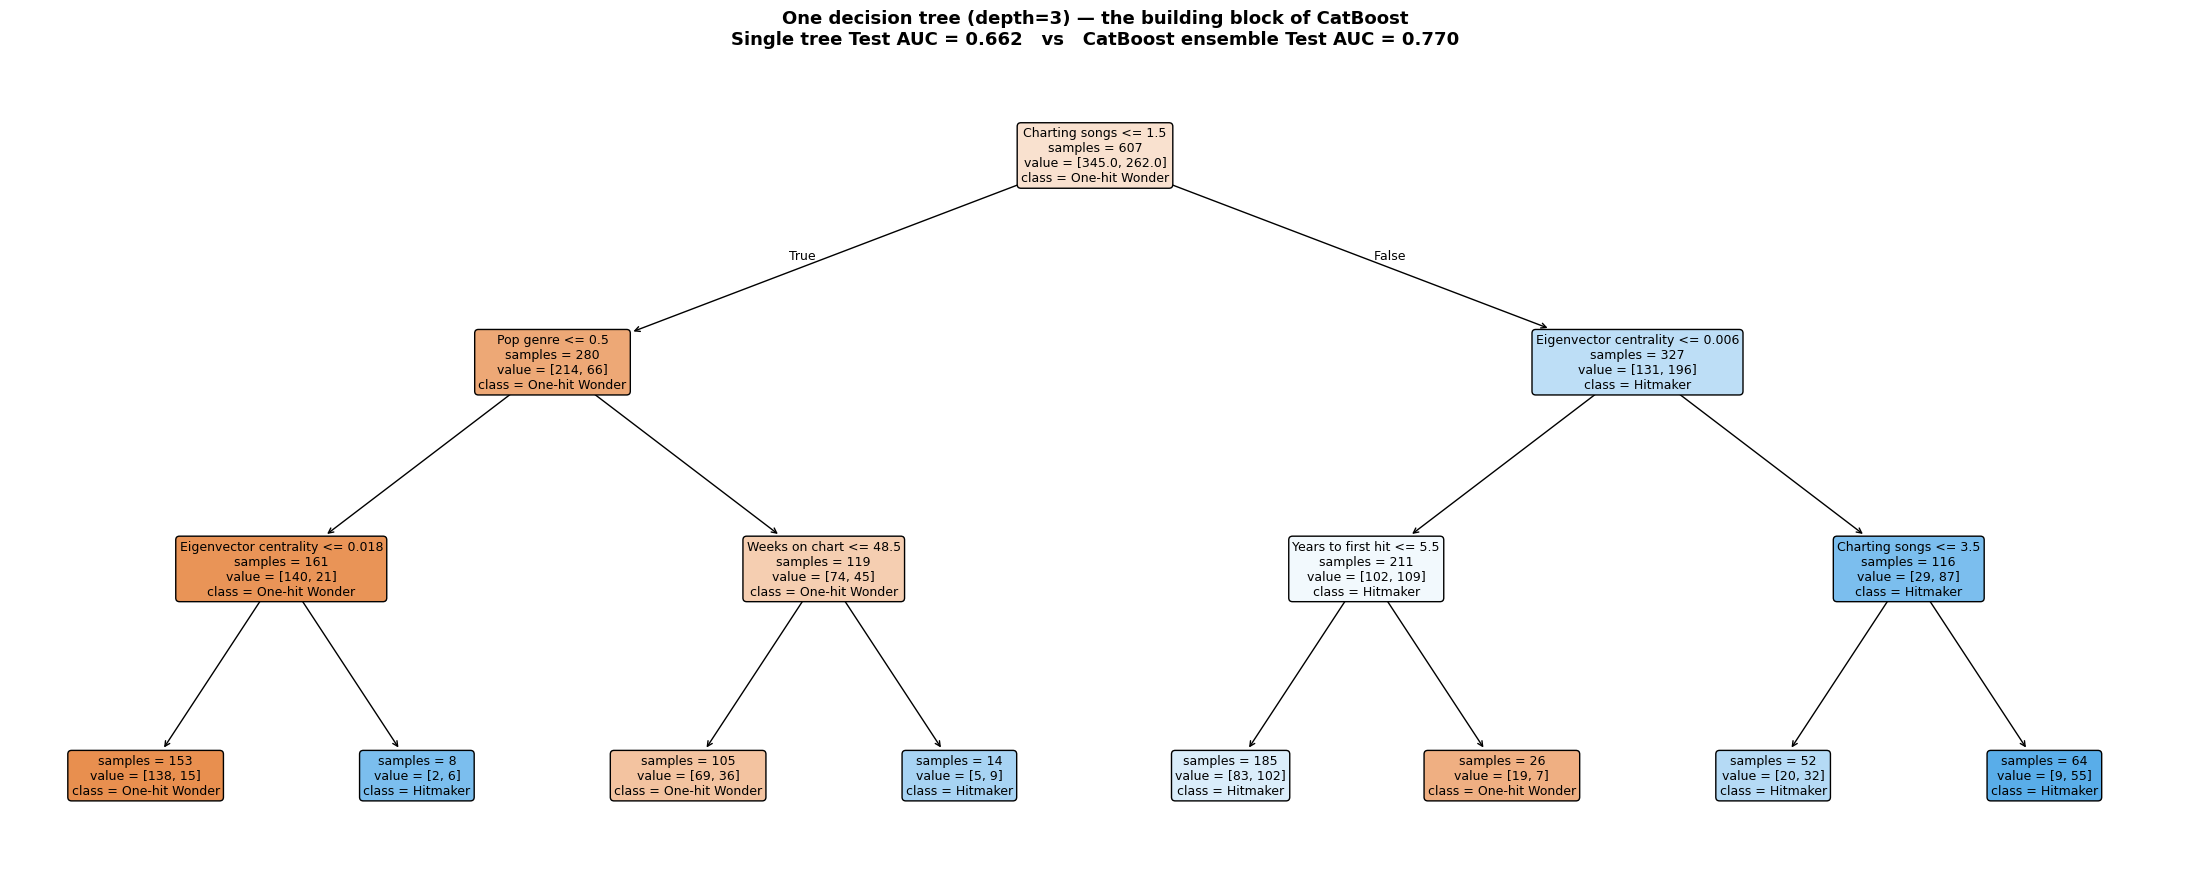

In [3]:
## 2. A single decision tree — the building block of CatBoost

# CatBoost uses 50 symmetric (oblivious) trees. In a symmetric tree, every branch at
# a given depth uses the SAME split condition — so depth=3 always means exactly
# 3 yes/no questions, and every tree always produces exactly 8 outcome leaves.
#
# Below: a DecisionTreeClassifier trained on CatBoost's 12 features at depth=3.
# This is a direct analog of one CatBoost boosting round.
# The full model combines 50 of these, each correcting errors of the previous.

from sklearn.tree import DecisionTreeClassifier, plot_tree as sk_plot_tree
from sklearn.tree import _tree

FEATURE_LABELS_CAT = {
    '#_of_charting_songs_through_first_top_20_hit': 'Charting songs',
    '#_of_genres_artist':                           'Num genres',
    'betweenness_centrality_top20_rolling5':        'Betweenness centrality',
    'artist_genre_Pop':                             'Pop genre',
    'harmonic_closeness_centrality_top20_rolling5': 'Harmonic closeness',
    'eigenvector_centrality_top20_rolling5':        'Eigenvector centrality',
    'years_through_first_top_20_hit':               'Years to first hit',
    'artist_genre_Hip Hop/Rap':                     'Hip Hop/Rap genre',
    'top_20_hit_song_#_wks_on_chart_any_position':  'Weeks on chart',
    'artist_genre_other':                           'Other genre',
    'artist_genre_R&B/Soul/Funk':                   'R&B/Soul/Funk genre',
    'artist_genre_Rock':                            'Rock genre',
}
BINARY_FEATS = {f for f in CAT_FEATURES if f.startswith('artist_genre_')}

tree_viz = DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE)
tree_viz.fit(X_train_cat[CAT_FEATURES], y_train)

train_auc_tree = roc_auc_score(y_train, tree_viz.predict_proba(X_train_cat[CAT_FEATURES])[:, 1])
test_auc_tree  = roc_auc_score(y_test,  tree_viz.predict_proba(X_test_cat[CAT_FEATURES])[:, 1])
cat_train_auc  = roc_auc_score(y_train, cat.predict_proba(X_train_cat[CAT_FEATURES])[:, 1])

root_feat   = FEATURE_LABELS_CAT.get(CAT_FEATURES[tree_viz.tree_.feature[0]], CAT_FEATURES[tree_viz.tree_.feature[0]])
root_thresh = tree_viz.tree_.threshold[0]
print(f'Root split: {root_feat} > {root_thresh:.1f}?')
print(f'This is the single most discriminating question the model can ask.')
print()
print(f'Single tree (depth=3):   Train AUC={train_auc_tree:.3f}, Test AUC={test_auc_tree:.3f}')
print(f'CatBoost ensemble (50):  Train AUC={cat_train_auc:.3f},  Test AUC={cat_auc:.3f}')
print(f'→ 50 trees combined are far stronger than any single tree.')

clean_names = [FEATURE_LABELS_CAT.get(f, f) for f in CAT_FEATURES]

fig, ax = plt.subplots(figsize=(22, 9))
sk_plot_tree(tree_viz, feature_names=clean_names,
             class_names=['One-hit Wonder', 'Hitmaker'],
             filled=True, rounded=True, fontsize=9, ax=ax,
             impurity=False, proportion=False)
ax.set_title(
    'One decision tree (depth=3) — the building block of CatBoost\n'
    f'Single tree Test AUC = {test_auc_tree:.3f}   vs   CatBoost ensemble Test AUC = {cat_auc:.3f}',
    fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

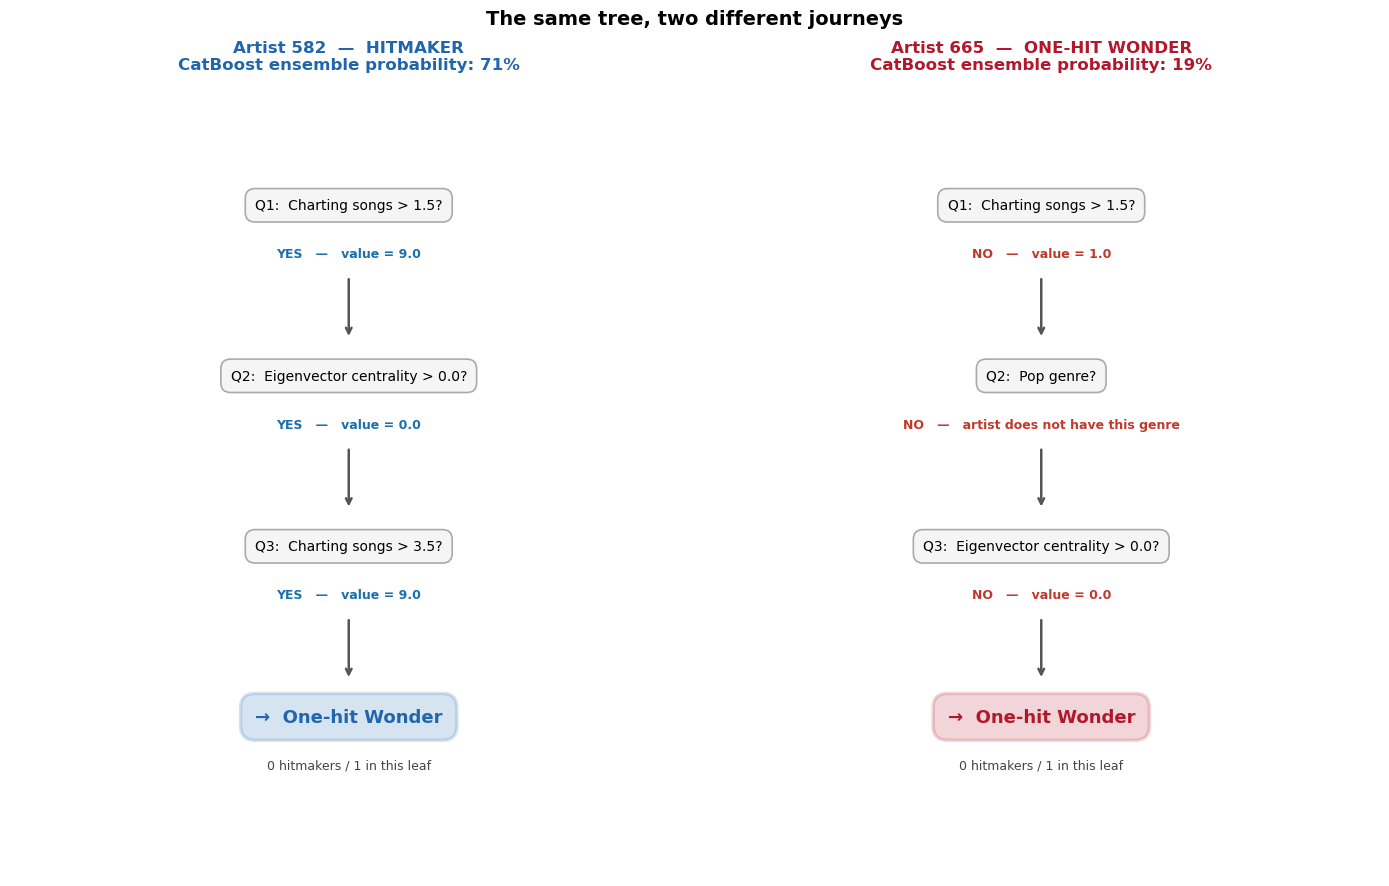

In [4]:
## 3. Walking through the tree: one hitmaker, one one-hit wonder

# We pick the most confidently correct prediction of each type from the test set,
# then trace their exact path through the tree above — 3 questions, one verdict.

def trace_path(clf, x_arr, feature_names, label_map, binary_feats):
    """Walk one sample through the tree. Returns list of step dicts."""
    tree_ = clf.tree_
    steps, node = [], 0
    while tree_.feature[node] != _tree.TREE_UNDEFINED:
        f_idx  = tree_.feature[node]
        thresh = tree_.threshold[node]
        fname  = feature_names[f_idx]
        val    = x_arr[f_idx]
        clean  = label_map.get(fname, fname)
        goes_left = val <= thresh
        if fname in binary_feats:
            question = f'{clean}?'
            answer   = 'YES' if not goes_left else 'NO'
            detail   = f'artist {"has" if not goes_left else "does not have"} this genre'
        else:
            question = f'{clean} > {thresh:.1f}?'
            answer   = 'YES' if not goes_left else 'NO'
            detail   = f'value = {val:.1f}'
        steps.append({'q': question, 'ans': answer, 'detail': detail})
        node = tree_.children_left[node] if goes_left else tree_.children_right[node]
    leaf_vals = tree_.value[node][0]
    n_hit = int(leaf_vals[1]);  n_tot = int(sum(leaf_vals))
    verdict = 'Hitmaker' if n_hit > (n_tot - n_hit) else 'One-hit Wonder'
    steps.append({'q': 'RESULT', 'ans': verdict,
                  'detail': f'{n_hit} hitmakers / {n_tot} in this leaf'})
    return steps

# Identify most confident TP and TN using the illustrative tree
_cat_p = cat.predict_proba(X_test_cat[CAT_FEATURES])[:, 1]
_tree_p = tree_viz.predict_proba(X_test_cat[CAT_FEATURES])[:, 1]
_tree_pred = tree_viz.predict(X_test_cat[CAT_FEATURES])

meta = pd.DataFrame({'y_true': y_test.values, 'tree_pred': _tree_pred,
                     'tree_prob': _tree_p, 'cat_prob': _cat_p}, index=y_test.index)

hit_idx  = meta[(meta['y_true']==1) & (meta['tree_pred']==1)].sort_values('tree_prob', ascending=False).index[0]
miss_idx = meta[(meta['y_true']==0) & (meta['tree_pred']==0)].sort_values('tree_prob').index[0]

hit_steps  = trace_path(tree_viz, X_test_cat.loc[hit_idx,  CAT_FEATURES].values,
                        CAT_FEATURES, FEATURE_LABELS_CAT, BINARY_FEATS)
miss_steps = trace_path(tree_viz, X_test_cat.loc[miss_idx, CAT_FEATURES].values,
                        CAT_FEATURES, FEATURE_LABELS_CAT, BINARY_FEATS)

# --- Visualization ---
fig, axes = plt.subplots(1, 2, figsize=(14, 9))

for ax, steps, aid, verdict, mc in [
    (axes[0], hit_steps,  hit_idx,  'HITMAKER',        '#2166ac'),
    (axes[1], miss_steps, miss_idx, 'ONE-HIT WONDER',  '#b2182b'),
]:
    n = len(steps)  # 3 questions + 1 result
    ax.set_xlim(-0.5, 10.5)
    ax.set_ylim(-1, n * 3.2)
    ax.axis('off')

    y_pos = [(n - 1 - i) * 3.0 + 1.5 for i in range(n)]

    for i, (step, y) in enumerate(zip(steps, y_pos)):
        is_result = step['q'] == 'RESULT'

        if is_result:
            bbox_kw  = dict(boxstyle='round,pad=0.8', facecolor=mc, alpha=0.18,
                            edgecolor=mc, linewidth=2.5)
            main_txt = f"→  {step['ans']}"
            sub_txt  = step['detail']
            main_fs, main_fw, main_col = 13, 'bold', mc
            sub_col = '#444444'
        else:
            bbox_kw  = dict(boxstyle='round,pad=0.7', facecolor='#f5f5f5',
                            edgecolor='#aaaaaa', linewidth=1.2)
            main_txt = f"Q{i+1}:  {step['q']}"
            sub_txt  = f"{step['ans']}   —   {step['detail']}"
            main_fs, main_fw, main_col = 10, 'normal', 'black'
            sub_col = '#1a6faf' if step['ans'] == 'YES' else '#c0392b'

        ax.text(5, y + 0.3, main_txt, ha='center', va='center',
                fontsize=main_fs, fontweight=main_fw, color=main_col,
                bbox=bbox_kw, zorder=5)
        ax.text(5, y - 0.55, sub_txt, ha='center', va='center',
                fontsize=9, color=sub_col,
                fontweight='bold' if not is_result else 'normal')

        if i < n - 1:
            ax.annotate('', xy=(5, y_pos[i+1] + 0.95), xytext=(5, y - 0.95),
                        arrowprops=dict(arrowstyle='->', color='#555555', lw=1.8))

    _prob = meta.loc[aid, 'cat_prob']
    ax.set_title(f'Artist {aid}  —  {verdict}\nCatBoost ensemble probability: {_prob:.0%}',
                 fontsize=12, fontweight='bold', color=mc, pad=16)

fig.suptitle('The same tree, two different journeys', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

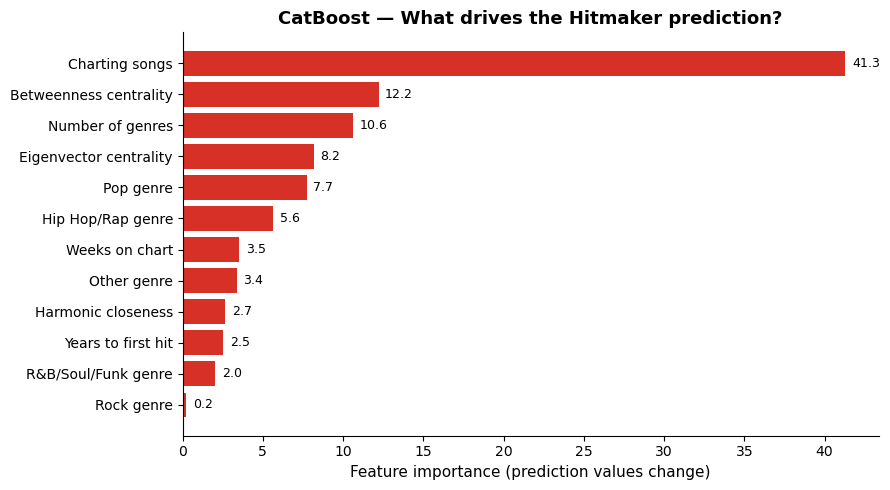

Charting songs = total number of songs that have appeared in the top 20.
This single feature accounts for the majority of predictive power.


In [5]:
## 4. What signals matter most

# CatBoost feature importance: PredictionValuesChange — how much each feature
# shifts the predicted probability across the training set on average.

imp_cat = cat.get_feature_importance()
imp_series = pd.Series(imp_cat, index=CAT_FEATURES).sort_values(ascending=True)

clean_labels_cat = {
    '#_of_charting_songs_through_first_top_20_hit': 'Charting songs',
    '#_of_genres_artist':                           'Number of genres',
    'betweenness_centrality_top20_rolling5':        'Betweenness centrality',
    'artist_genre_Pop':                             'Pop genre',
    'harmonic_closeness_centrality_top20_rolling5': 'Harmonic closeness',
    'eigenvector_centrality_top20_rolling5':        'Eigenvector centrality',
    'years_through_first_top_20_hit':               'Years to first hit',
    'artist_genre_Hip Hop/Rap':                     'Hip Hop/Rap genre',
    'top_20_hit_song_#_wks_on_chart_any_position':  'Weeks on chart',
    'artist_genre_other':                           'Other genre',
    'artist_genre_R&B/Soul/Funk':                   'R&B/Soul/Funk genre',
    'artist_genre_Rock':                            'Rock genre',
}
imp_series.index = [clean_labels_cat.get(i, i) for i in imp_series.index]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(imp_series.index, imp_series.values, color='#d73027')
ax.set_xlabel('Feature importance (prediction values change)', fontsize=11)
ax.set_title('CatBoost — What drives the Hitmaker prediction?', fontsize=13, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)
for bar, val in zip(bars, imp_series.values):
    ax.text(val + imp_series.max() * 0.01, bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()
print('Charting songs = total number of songs that have appeared in the top 20.')
print('This single feature accounts for the majority of predictive power.')

                    CatBoost ✓  Random Forest        XGBoost
Metric                                                      
CV AUC †      0.769 ± 0.023  ✓  0.753 ± 0.027  0.754 ± 0.024
Test AUC                 0.770          0.767          0.772
Overfit Gap             +0.021         +0.019       −0.003 ‡
F1 Score              0.680  ✓          0.653          0.652
Precision                0.607       0.603  ✓          0.613
Recall                0.773  ✓          0.712          0.697
N Features                  12              9           7  ✓
Total Trees              50  ✓            409            239
Max Depth                    3              2              5
Total Leaves            400  ✓           1590            468


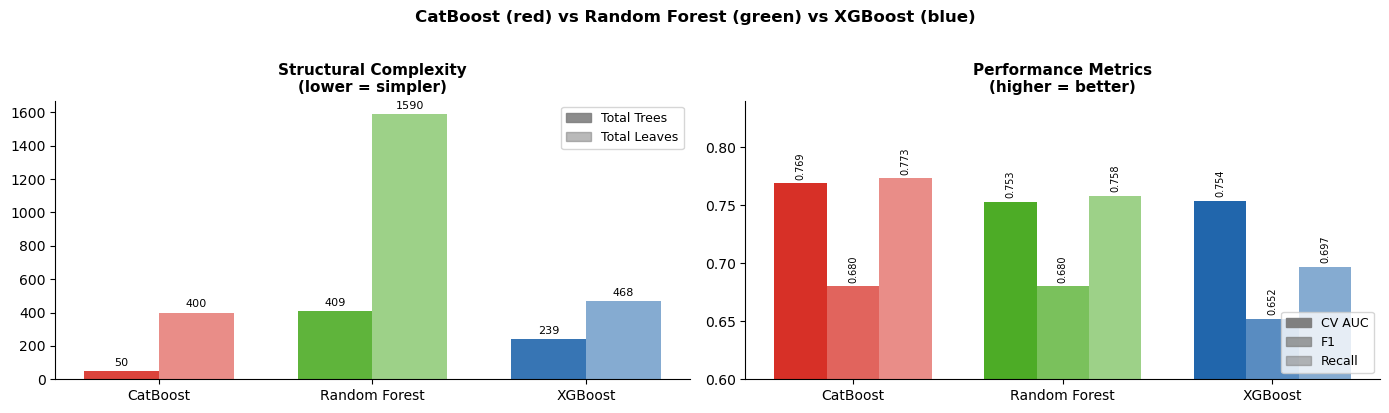


† CV AUC from nb23 (5-fold, paired t-test):
    CatBoost vs XGBoost: p=0.021  → statistically significant
    CatBoost vs RF:      p=0.103  → real trend, not yet proven at 5 folds
    XGBoost  vs RF:      p=0.756  → statistically tied

‡ XGBoost negative overfit gap is a regularization artifact —
  aggressive penalties suppress training AUC; test AUC "win" is a lucky split.

Recommendation: CatBoost.
  • Statistically better CV AUC, best recall, tied F1, fewest trees and leaves.
Runner-up: RF — tied F1, best precision; reconsider if false alarms are costly.
Eliminated: XGBoost — worst F1 and recall; test AUC advantage does not hold in CV.


In [6]:
## 5. CatBoost vs XGBoost vs RF — model selection rationale
#
# Full statistical comparison is in nb23 (paired t-test, lift curves, disagreement analysis).
# Key finding: CatBoost significantly outperforms XGBoost in 5-fold CV (p=0.021).

from sklearn.metrics import log_loss
from sklearn.ensemble import RandomForestClassifier

# RF pipeline params (nb21 final selection, n=9 features)
RF_FEATURES = [
    '#_of_charting_songs_through_first_top_20_hit', '#_of_genres_artist',
    'artist_genre_Hip Hop/Rap', 'artist_genre_Pop', 'artist_genre_unknown',
    'top_20_hit_song_#_wks_on_chart_any_position', 'artist_genre_R&B/Soul/Funk',
    'years_through_first_top_20_hit', 'artist_genre_other',
]
RF_PARAMS = dict(n_estimators=409, max_depth=2, min_samples_leaf=17,
                 max_features='sqrt', class_weight='balanced',
                 random_state=RANDOM_STATE, n_jobs=-1)

# X_train/X_test with artist_genre_other (already computed for CatBoost set)
rf = RandomForestClassifier(**RF_PARAMS)
rf.fit(X_train_cat[RF_FEATURES], y_train)

xgb_proba = xgb.predict_proba(X_test_imp[XGB_FEATURES])[:, 1]
cat_proba  = cat.predict_proba(X_test_cat[CAT_FEATURES])[:, 1]
rf_proba   = rf.predict_proba(X_test_cat[RF_FEATURES])[:, 1]

xgb_pred = (xgb_proba >= 0.44).astype(int)
cat_pred  = (cat_proba  >= 0.40).astype(int)
rf_pred   = (rf_proba   >= 0.49).astype(int)

comparison = pd.DataFrame({
    'Metric': ['CV AUC †', 'Test AUC', 'Overfit Gap', 'F1 Score', 'Precision',
               'Recall', 'N Features', 'Total Trees', 'Max Depth', 'Total Leaves'],
    'CatBoost ✓': [
        '0.769 ± 0.023  ✓',
        f'{roc_auc_score(y_test, cat_proba):.3f}',
        '+0.021',
        f'{f1_score(y_test, cat_pred):.3f}  ✓',
        f'{precision_score(y_test, cat_pred):.3f}',
        f'{recall_score(y_test, cat_pred):.3f}  ✓',
        '12', '50  ✓', '3', '400  ✓',
    ],
    'Random Forest': [
        '0.753 ± 0.027',
        f'{roc_auc_score(y_test, rf_proba):.3f}',
        '+0.019',
        f'{f1_score(y_test, rf_pred):.3f}',
        f'{precision_score(y_test, rf_pred):.3f}  ✓',
        f'{recall_score(y_test, rf_pred):.3f}',
        '9', '409', '2', '1590',
    ],
    'XGBoost': [
        '0.754 ± 0.024',
        f'{roc_auc_score(y_test, xgb_proba):.3f}',
        '−0.003 ‡',
        f'{f1_score(y_test, xgb_pred):.3f}',
        f'{precision_score(y_test, xgb_pred):.3f}',
        f'{recall_score(y_test, xgb_pred):.3f}',
        '7  ✓', '239', '5', '468',
    ],
}).set_index('Metric')

print(comparison.to_string())

# Complexity + performance chart
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
colors = ['#d73027', '#4dac26', '#2166ac']
model_names = ['CatBoost', 'Random Forest', 'XGBoost']

# Left: complexity bars (Total Trees + Total Leaves side by side)
ax = axes[0]
x, w = np.arange(3), 0.35
for j, (vals, lbl, alpha) in enumerate(zip(
        [[50, 409, 239], [400, 1590, 468]], ['Total Trees', 'Total Leaves'], [0.9, 0.55])):
    for i, (v, c) in enumerate(zip(vals, colors)):
        ax.bar(i + (j-0.5)*w, v, w, color=c, alpha=alpha, label=lbl if i == 0 else '')
        ax.text(i + (j-0.5)*w, v + 20, str(v), ha='center', va='bottom', fontsize=8)
ax.set_xticks(np.arange(3));  ax.set_xticklabels(model_names, fontsize=10)
ax.set_title('Structural Complexity\n(lower = simpler)', fontsize=11, fontweight='bold')
handles = [plt.Rectangle((0,0),1,1, color='gray', alpha=a) for a in [0.9, 0.55]]
ax.legend(handles, ['Total Trees', 'Total Leaves'], fontsize=9)
ax.spines[['top','right']].set_visible(False)

# Right: key performance metrics
ax = axes[1]
metrics_data = {
    'CV AUC':  [0.769, 0.753, 0.754],
    'F1':      [0.680, 0.680, 0.652],
    'Recall':  [0.773, 0.758, 0.697],
}
x = np.arange(3)
for j, (lbl, vals) in enumerate(metrics_data.items()):
    offset = (j - 1) * 0.25
    for i, (v, c) in enumerate(zip(vals, colors)):
        ax.bar(i + offset, v, 0.25, color=c, alpha=[1.0, 0.75, 0.55][j],
               label=lbl if i == 0 else '')
        ax.text(i + offset, v + 0.003, f'{v:.3f}',
                ha='center', va='bottom', fontsize=7, rotation=90)
ax.set_xticks(x);  ax.set_xticklabels(model_names, fontsize=10)
ax.set_ylim(0.60, 0.84)
ax.set_title('Performance Metrics\n(higher = better)', fontsize=11, fontweight='bold')
handles = [plt.Rectangle((0,0),1,1, color='gray', alpha=a) for a in [1.0, 0.75, 0.55]]
ax.legend(handles, ['CV AUC', 'F1', 'Recall'], fontsize=9, loc='lower right')
ax.spines[['top','right']].set_visible(False)

plt.suptitle('CatBoost (red) vs Random Forest (green) vs XGBoost (blue)',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print()
print('† CV AUC from nb23 (5-fold, paired t-test):')
print('    CatBoost vs XGBoost: p=0.021  → statistically significant')
print('    CatBoost vs RF:      p=0.103  → real trend, not yet proven at 5 folds')
print('    XGBoost  vs RF:      p=0.756  → statistically tied')
print()
print('‡ XGBoost negative overfit gap is a regularization artifact —')
print('  aggressive penalties suppress training AUC; test AUC "win" is a lucky split.')
print()
print('Recommendation: CatBoost.')
print('  • Statistically better CV AUC, best recall, tied F1, fewest trees and leaves.')
print('Runner-up: RF — tied F1, best precision; reconsider if false alarms are costly.')
print('Eliminated: XGBoost — worst F1 and recall; test AUC advantage does not hold in CV.')

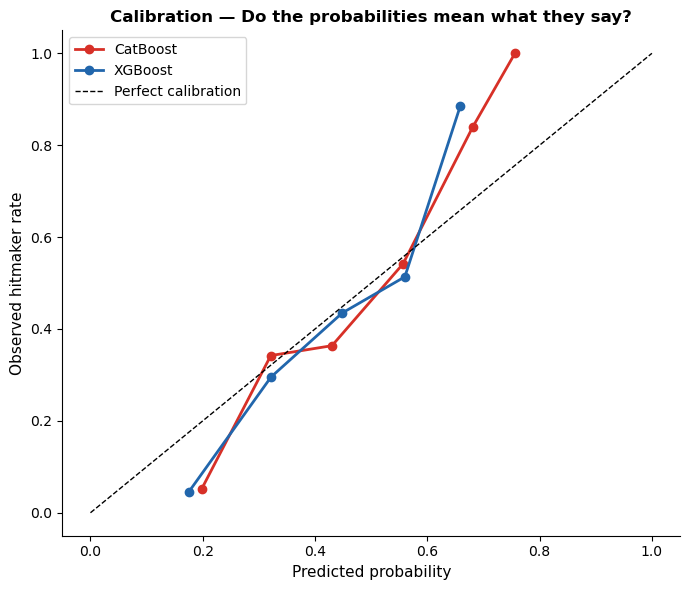

A point on the diagonal means: when the model gives X% probability, X% of those
artists actually became hitmakers. Deviation above = model is underconfident;
deviation below = overconfident.


In [7]:
## 6. Can we trust the probabilities?

# Calibration curve: if the model says 70%, are ~70% of those artists hitmakers?
# A well-calibrated model follows the diagonal (perfect calibration).

fig, ax = plt.subplots(figsize=(7, 6))

for proba, label, color in [
    (cat_proba,  'CatBoost', '#d73027'),
    (xgb_proba,  'XGBoost',  '#2166ac'),
]:
    frac_pos, mean_pred = calibration_curve(y_test, proba, n_bins=8)
    ax.plot(mean_pred, frac_pos, 'o-', label=label, color=color, linewidth=2)

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Perfect calibration')
ax.set_xlabel('Predicted probability', fontsize=11)
ax.set_ylabel('Observed hitmaker rate', fontsize=11)
ax.set_title('Calibration — Do the probabilities mean what they say?',
             fontsize=12, fontweight='bold')
ax.legend()
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()
print('A point on the diagonal means: when the model gives X% probability, X% of those')
print('artists actually became hitmakers. Deviation above = model is underconfident;')
print('deviation below = overconfident.')

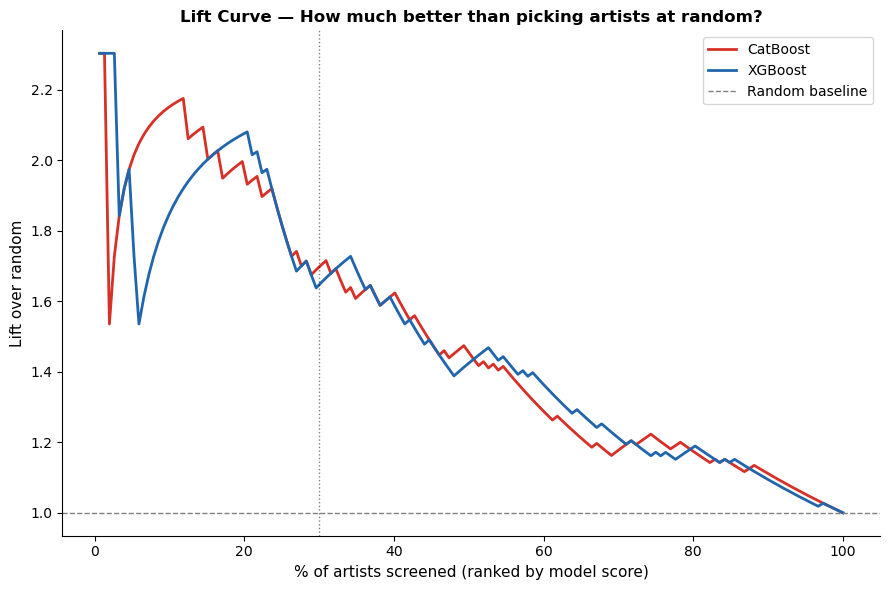

Top 10% screened → CatBoost lift: 2.15x   XGBoost lift: 1.84x
Top 20% screened → CatBoost lift: 2.00x   XGBoost lift: 2.07x
Top 30% screened → CatBoost lift: 1.69x   XGBoost lift: 1.64x
Top 50% screened → CatBoost lift: 1.45x   XGBoost lift: 1.42x


In [8]:
## 7. Lift curve — how much better than random?

# Lift = how many times more hitmakers we find vs random screening.
# At 30% screening: lift of 2.0 means we find 2× more hitmakers than chance.

def compute_lift(y_true, y_score):
    order    = np.argsort(y_score)[::-1]
    y_sorted = np.array(y_true)[order]
    base_rate = y_true.mean()
    n = len(y_true)
    fracs, lifts = [], []
    for k in range(1, n + 1):
        frac = k / n
        hit_rate = y_sorted[:k].mean()
        lifts.append(hit_rate / base_rate if base_rate > 0 else 0)
        fracs.append(frac)
    return np.array(fracs), np.array(lifts)

fig, ax = plt.subplots(figsize=(9, 6))

for proba, label, color in [
    (cat_proba,  'CatBoost', '#d73027'),
    (xgb_proba,  'XGBoost',  '#2166ac'),
]:
    fracs, lifts = compute_lift(y_test.values, proba)
    ax.plot(fracs * 100, lifts, label=label, color=color, linewidth=2)

ax.axhline(1.0, color='gray', linestyle='--', linewidth=1, label='Random baseline')
ax.axvline(30, color='black', linestyle=':', linewidth=1, alpha=0.5)

ax.set_xlabel('% of artists screened (ranked by model score)', fontsize=11)
ax.set_ylabel('Lift over random', fontsize=11)
ax.set_title('Lift Curve — How much better than picking artists at random?',
             fontsize=12, fontweight='bold')
ax.legend()
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

for pct in [10, 20, 30, 50]:
    idx = int(pct / 100 * len(y_test)) - 1
    fracs_c, lifts_c = compute_lift(y_test.values, cat_proba)
    fracs_x, lifts_x = compute_lift(y_test.values, xgb_proba)
    print(f'Top {pct:2d}% screened → CatBoost lift: {lifts_c[idx]:.2f}x   XGBoost lift: {lifts_x[idx]:.2f}x')